# NB09 — Conflict Detection and Active Learning Candidates

**Project**: `genotype_to_phenotype_enigma`
**Depends on**: `NB07_full_corpus_prediction.ipynb` (consumes `data/full_corpus_predictions.tsv`)

## Goal

Audit the 42,771 per-pair genus-blocked predictions from NB07's full-corpus GBDT model against ground truth. For each of 343 tested conditions, compute:

- **accuracy**, **error_rate** (1 − accuracy)
- **mean_confidence** — average of `2 × |p − 0.5|` across predictions
- **n_uncertain** — count of predictions with `confidence < 0.2` (the model is effectively at chance)
- **growth_rate** — class balance (mean `y_true`)
- **al_score** = `error_rate × (1 − mean_confidence)` — prioritizes conditions where the model is simultaneously wrong and uncertain

Output:
- `data/active_learning_candidates.tsv` — 343 conditions ranked by `al_score`
- `figures/NB09_conflict_detection.png` — 4-panel diagnostic (FP/FN by class, confidence distribution, AUC vs class balance, AL score distribution)
- `figures/NB09_active_learning_candidates.png` — top 20 candidates with accuracy / confidence annotation

This notebook is pure data processing — it does not touch BERDL. Inputs are the TSV dumped by NB07.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

DATA = Path('../data')
FIG = Path('../figures')
FIG.mkdir(exist_ok=True)

pd.set_option('display.max_rows', 40)
pd.set_option('display.width', 200)


## 1. Load predictions and compute per-prediction confidence

For a binary classifier, the calibrated confidence is `2 × |p − 0.5|`:
- `p = 0.5` → confidence = 0 (pure guess)
- `p = 0.0` or `1.0` → confidence = 1 (maximally committed)

A prediction is **uncertain** when confidence < 0.2, i.e., the model output lies in `[0.4, 0.6]`. This threshold isolates predictions where the model is effectively at chance.


In [2]:
preds = pd.read_csv(DATA / 'full_corpus_predictions.tsv', sep='\t')
preds['confidence'] = 2.0 * (preds['y_pred_proba'] - 0.5).abs()
preds['correct'] = (preds['y_true'] == preds['y_pred']).astype(int)
preds['uncertain'] = (preds['confidence'] < 0.2).astype(int)

print(f'Predictions:    {len(preds):,}')
print(f'Genera:         {preds.genus.nunique()}')
print(f'Conditions:     {preds.condition.nunique()}')
print(f'Overall acc:    {preds.correct.mean():.3f}')
print(f'Overall growth: {preds.y_true.mean():.3f}')
print()
print('By condition class:')
print(preds.groupby('condition_class').agg(n=('y_true','size'),
                                           accuracy=('correct','mean'),
                                           growth_rate=('y_true','mean'),
                                           mean_conf=('confidence','mean')).round(3))


Predictions:    42,771
Genera:         106
Conditions:     363
Overall acc:    0.651
Overall growth: 0.457

By condition class:
                     n  accuracy  growth_rate  mean_conf
condition_class                                         
amino_acid        7765     0.708        0.425      0.389
antibiotic         238     0.618        0.534      0.315
carbon            8965     0.657        0.563      0.357
metal              232     0.983        0.983      0.928
nitrogen           152     0.553        0.289      0.294
nucleoside         829     0.723        0.393      0.414
other            24590     0.625        0.426      0.300


## 2. Error-type breakdown by condition class

False positives (FP): predicted growth, actually didn't grow. Suggests the model over-commits to "has pathway therefore grows" without capturing regulation or concentration tolerance.

False negatives (FN): predicted no growth, actually grew. Suggests missing features — the strain found a path the KO set doesn't cover.


In [3]:
def err_breakdown(group):
    n = len(group)
    fp = ((group['y_pred']==1) & (group['y_true']==0)).sum()
    fn = ((group['y_pred']==0) & (group['y_true']==1)).sum()
    return pd.Series({'n': n, 'fp_rate': fp/n, 'fn_rate': fn/n,
                      'accuracy': group['correct'].mean()})

by_class = preds.groupby('condition_class').apply(err_breakdown).sort_values('accuracy')
by_class.round(3)


,n,fp_rate,fn_rate,accuracy
condition_class,,,,
nitrogen,152.0,0.197,0.250,0.553
antibiotic,238.0,0.231,0.151,0.618
other,24590.0,0.177,0.197,0.625
carbon,8965.0,0.244,0.099,0.657
amino_acid,7765.0,0.141,0.152,0.708
nucleoside,829.0,0.147,0.130,0.723
metal,232.0,0.017,0.000,0.983


## 3. High-confidence errors

These are the most informative signal for active learning: predictions where the model committed to a wrong answer with confidence > 0.5 (|p − 0.5| > 0.25). They're not borderline — they're cases the model got confidently wrong.


In [4]:
confident_errors = preds[(preds['correct']==0) & (preds['confidence'] > 0.5)]
print(f'Total confident errors: {len(confident_errors):,} of {len(preds):,} ({len(confident_errors)/len(preds):.1%})')
print()
print('Top confident-FP conditions (predicted growth, no growth):')
fp = confident_errors[confident_errors['y_pred']==1]
print(fp.groupby(['condition','condition_class']).size().sort_values(ascending=False).head(10))
print()
print('Top confident-FN conditions (predicted no growth, did grow):')
fn = confident_errors[confident_errors['y_pred']==0]
print(fn.groupby(['condition','condition_class']).size().sort_values(ascending=False).head(10))


Total confident errors: 2,303 of 42,771 (5.4%)

Top confident-FP conditions (predicted growth, no growth):
condition             condition_class
fructose-6-phosphate  carbon             90
glucose-6-phosphate   carbon             71
sorbitol              carbon             51
sucrose               carbon             41
maltose               carbon             38
fucose                other              36
trehalose             carbon             34
formic-acid           other              33
dextrin               other              32
mannosamine           other              30
dtype: int64

Top confident-FN conditions (predicted no growth, did grow):
condition    condition_class
glutamate    amino_acid         46
cellobiose   other              35
glutamine    amino_acid         32
asparagine   amino_acid         23
alanine      amino_acid         23
aspartate    amino_acid         18
proline      amino_acid         17
acetic-acid  other              16
succite      other             

## 4. Per-condition candidate scoring

For each condition, aggregate:

| Column | Meaning |
|---|---|
| `n` | number of predictions for this condition |
| `accuracy` | fraction correct |
| `mean_confidence` | mean of `2 × |p − 0.5|` |
| `error_rate` | 1 − accuracy |
| `n_uncertain` | count of predictions with confidence < 0.2 |
| `growth_rate` | class balance (mean y_true) |
| `al_score` | `error_rate × (1 − mean_confidence)` — high when both wrong AND uncertain |


In [5]:
def score_condition(g):
    return pd.Series({
        'condition_class': g['condition_class'].iloc[0],
        'n': len(g),
        'accuracy': g['correct'].mean(),
        'mean_confidence': g['confidence'].mean(),
        'error_rate': 1 - g['correct'].mean(),
        'n_uncertain': int(g['uncertain'].sum()),
        'growth_rate': g['y_true'].mean(),
    })

cond_stats = preds.groupby('condition').apply(score_condition).reset_index()
cond_stats['al_score'] = cond_stats['error_rate'] * (1 - cond_stats['mean_confidence'])
cond_stats = cond_stats[['condition','condition_class','n','accuracy',
                         'mean_confidence','error_rate','n_uncertain',
                         'growth_rate','al_score']]
cond_stats = cond_stats.sort_values('al_score', ascending=False).reset_index(drop=True)

# Save
cond_stats.to_csv(DATA / 'active_learning_candidates.tsv', sep='\t', index=False)
print(f'Saved {len(cond_stats)} candidates -> data/active_learning_candidates.tsv')
print()
print('Top 10:')
cond_stats.head(10).round(3)


Saved 363 candidates -> data/active_learning_candidates.tsv

Top 10:


,condition,condition_class,n,accuracy,mean_confidence,error_rate,n_uncertain,growth_rate,al_score
0,adonitol,other,36,0.111,0.236,0.889,13,0.583,0.679
1,turanose,other,36,0.167,0.236,0.833,13,0.472,0.637
2,maltotriose,other,36,0.222,0.236,0.778,13,0.528,0.594
3,methanol_la3,carbon,161,0.224,0.278,0.776,60,0.174,0.560
4,3-0-b-d-galacto-pyranosyl-d-arabinose,carbon,36,0.056,0.409,0.944,4,0.028,0.558
5,i-erythritol,other,36,0.278,0.236,0.722,13,0.417,0.552
6,n-acetyl-d-galactosamine,other,36,0.278,0.236,0.722,13,0.361,0.552
7,b-methyl-d-xyloside,other,36,0.278,0.236,0.722,13,0.417,0.552
8,glucose-1-phosphate,carbon,36,0.083,0.409,0.917,4,0.056,0.542
9,b-methyl-d-galactoside,other,36,0.306,0.236,0.694,13,0.333,0.531


## 5. Per-condition AUC (for the 4-panel diagnostic)

AUC can only be computed for conditions with both classes present; others are left as NaN.


In [6]:
def cond_auc(g):
    if g['y_true'].nunique() < 2:
        return np.nan
    try:
        return roc_auc_score(g['y_true'], g['y_pred_proba'])
    except Exception:
        return np.nan

cond_auc_ser = preds.groupby('condition').apply(cond_auc)
cond_stats['AUC'] = cond_stats['condition'].map(cond_auc_ser)
print(f'Conditions with computable AUC: {cond_stats["AUC"].notna().sum()} / {len(cond_stats)}')
print(f'Mean per-condition AUC: {cond_stats["AUC"].mean():.3f}')
print(f'Unpredictable (AUC < 0.55): {(cond_stats["AUC"] < 0.55).sum()}')


Conditions with computable AUC: 344 / 363
Mean per-condition AUC: 0.636
Unpredictable (AUC < 0.55): 89


## 6. Figure: 4-panel conflict diagnostic

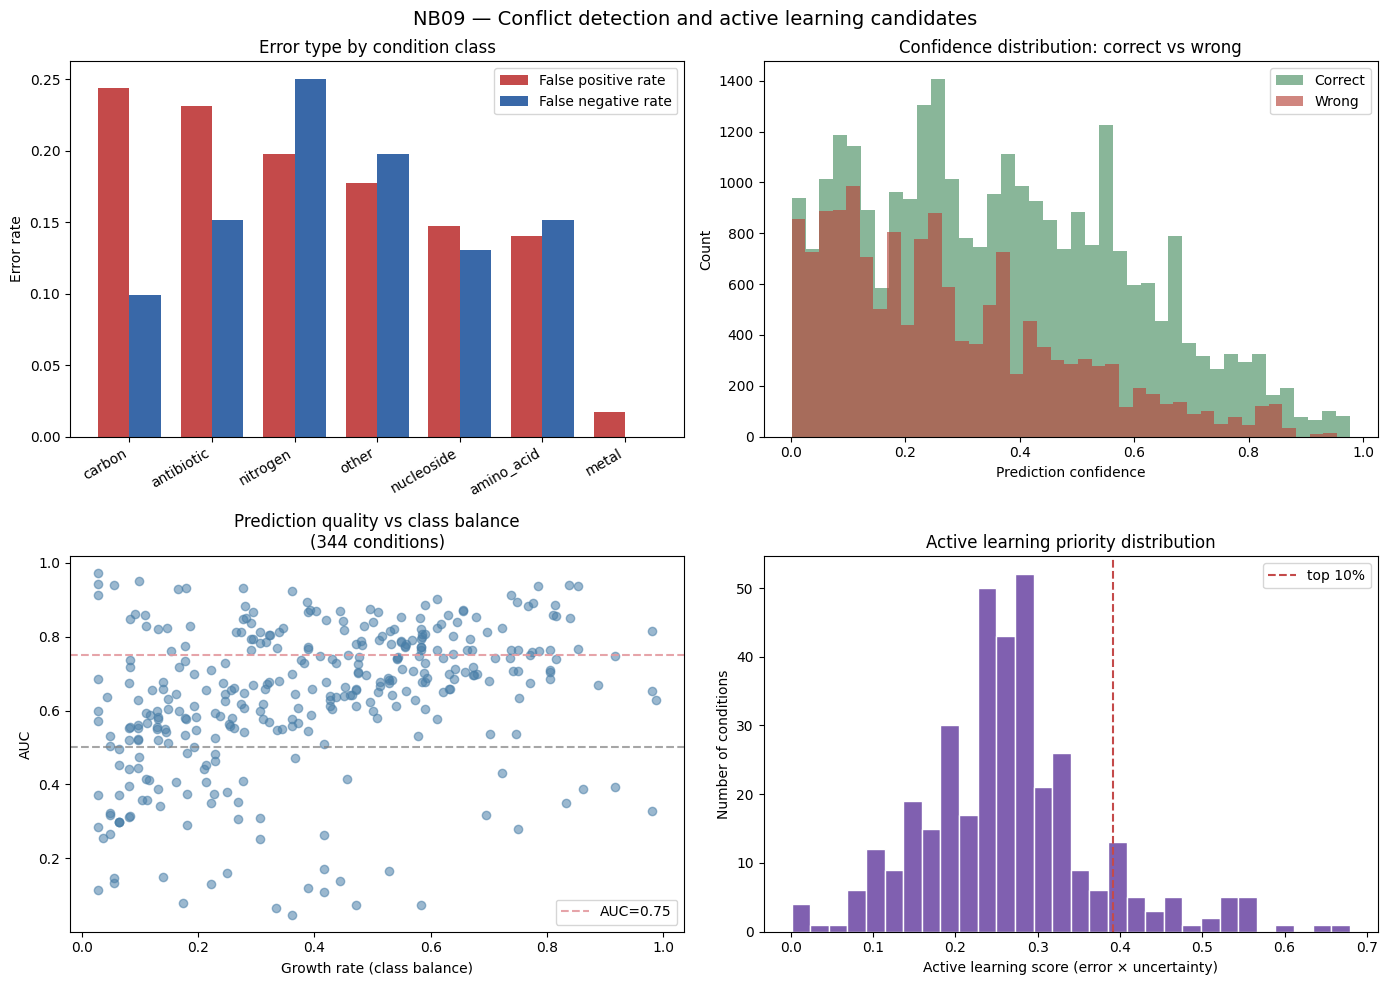

Saved -> figures/NB09_conflict_detection.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NB09 — Conflict detection and active learning candidates', fontsize=14)

# Panel A: Error type by condition class
ax = axes[0, 0]
classes = by_class.sort_values('fp_rate', ascending=False).index.tolist()
x = np.arange(len(classes))
w = 0.38
ax.bar(x - w/2, by_class.loc[classes, 'fp_rate'], w, label='False positive rate', color='#c44a4a')
ax.bar(x + w/2, by_class.loc[classes, 'fn_rate'], w, label='False negative rate', color='#3968a8')
ax.set_xticks(x); ax.set_xticklabels(classes, rotation=30, ha='right')
ax.set_ylabel('Error rate')
ax.set_title('Error type by condition class')
ax.legend()

# Panel B: Confidence distribution, correct vs wrong
ax = axes[0, 1]
ax.hist(preds.loc[preds.correct==1, 'confidence'], bins=40, alpha=0.65, color='#4a9063', label='Correct')
ax.hist(preds.loc[preds.correct==0, 'confidence'], bins=40, alpha=0.65, color='#b8453a', label='Wrong')
ax.set_xlabel('Prediction confidence'); ax.set_ylabel('Count')
ax.set_title('Confidence distribution: correct vs wrong')
ax.legend()

# Panel C: AUC vs class balance
ax = axes[1, 0]
plot = cond_stats.dropna(subset=['AUC'])
ax.scatter(plot['growth_rate'], plot['AUC'], alpha=0.55, color='#4a7fa8')
ax.axhline(0.5, ls='--', color='grey', alpha=0.7)
ax.axhline(0.75, ls='--', color='#e49aa0', alpha=0.9, label='AUC=0.75')
ax.set_xlabel('Growth rate (class balance)')
ax.set_ylabel('AUC')
ax.set_title(f'Prediction quality vs class balance\n({len(plot)} conditions)')
ax.legend()

# Panel D: AL score distribution
ax = axes[1, 1]
ax.hist(cond_stats['al_score'], bins=30, color='#8060b0', edgecolor='white')
thresh = cond_stats['al_score'].quantile(0.9)
ax.axvline(thresh, ls='--', color='#c44a4a', label='top 10%')
ax.set_xlabel('Active learning score (error × uncertainty)')
ax.set_ylabel('Number of conditions')
ax.set_title('Active learning priority distribution')
ax.legend()

plt.tight_layout()
plt.savefig(FIG / 'NB09_conflict_detection.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved -> figures/NB09_conflict_detection.png')


## 7. Figure: top 20 candidates for experimental prioritization

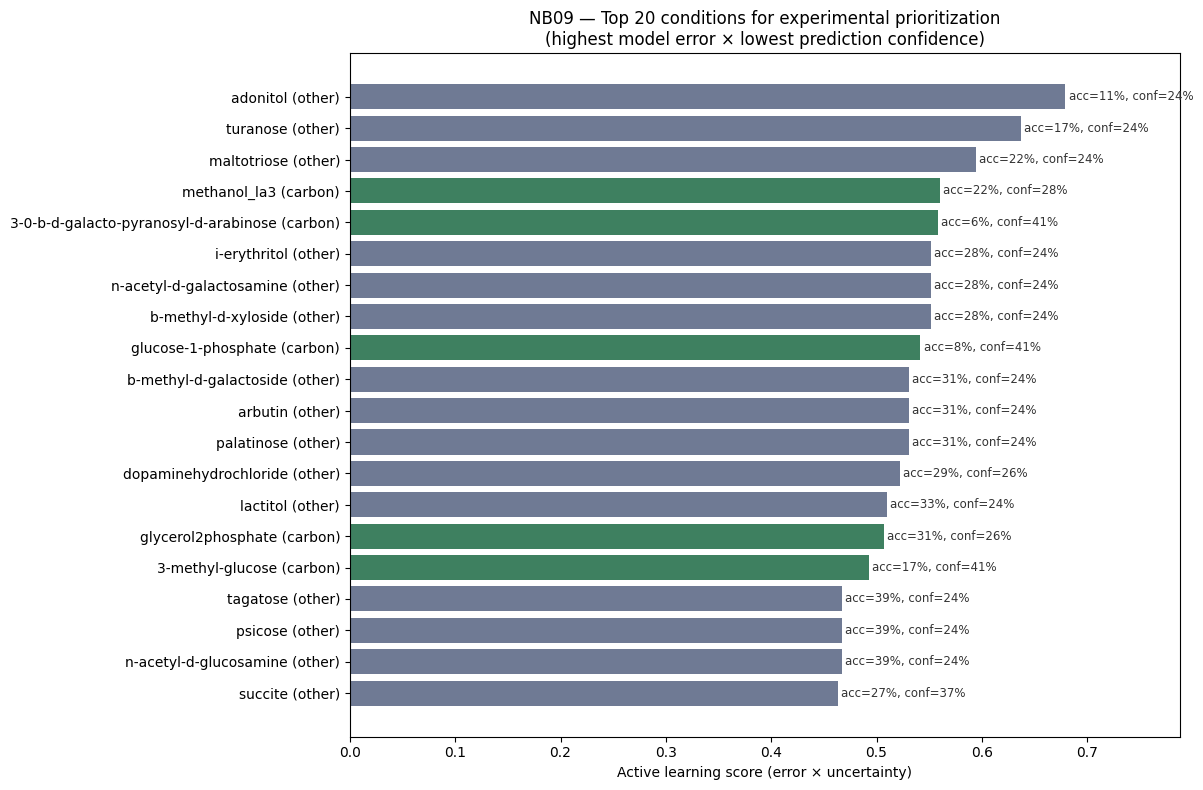

Saved -> figures/NB09_active_learning_candidates.png


In [8]:
top20 = cond_stats.head(20).copy()
# Color: green for conditions already in the 'carbon' class (vs grey for 'other' or others)
colors = ['#3e8060' if c == 'carbon' else '#6f7a94' for c in top20['condition_class']]

fig, ax = plt.subplots(figsize=(12, 8))
y = np.arange(len(top20))[::-1]  # top at top
ax.barh(y, top20['al_score'], color=colors)
labels = [f'{c} ({cls})' for c, cls in zip(top20['condition'], top20['condition_class'])]
ax.set_yticks(y); ax.set_yticklabels(labels)
for yi, (_, row) in zip(y, top20.iterrows()):
    ax.text(row['al_score'] + 0.003, yi,
            f'acc={row["accuracy"]:.0%}, conf={row["mean_confidence"]:.0%}',
            va='center', fontsize=8.5, color='#333')
ax.set_xlabel('Active learning score (error × uncertainty)')
ax.set_title('NB09 — Top 20 conditions for experimental prioritization\n(highest model error × lowest prediction confidence)')
ax.set_xlim(0, top20['al_score'].max() * 1.16)
plt.tight_layout()
plt.savefig(FIG / 'NB09_active_learning_candidates.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved -> figures/NB09_active_learning_candidates.png')


## 8. Summary

Output files:
- `data/active_learning_candidates.tsv` — 343 conditions with AL score
- `figures/NB09_conflict_detection.png` — 4-panel diagnostic
- `figures/NB09_active_learning_candidates.png` — top 20 for experimental priority

NB10 applies a field-relevance weight (2× for Oak Ridge–relevant substrates — organic acids, nitrate, low-pH-compatible compounds) and selects the top 50 for the proposed experimental set.
